# E Commerce Funnel analysis 

### Python Eda and Data cleaning Codes

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14,6)
plt.rcParams['font.size'] = 12

In [ ]:

df = pd.read_csv(r'C:\Users\HP\Downloads\ecommerce_funnel_raw.csv')

In [ ]:
df.head(5)


,user_id,session_id,event_timestamp,event_stage,device,source,country,product_id,product_category,product_price,quantity,order_id,payment_method,revenue,time_on_page_sec
0,USR_044325,USR_044325_S5,2025-10-05 15:34:00,product_view,mobile,google,USA,PROD_0245,Sports,8.29,NaN,NaN,NaN,NaN,49.9
1,USR_017506,USR_017506_S1,2025-12-05 11:34:00,confirmation,desktop,google,USA,PROD_0397,Clothing,48.72,1.0,ORD_018448,credit_card,50.59,4.1
2,USR_006946,USR_006946_S3,2025-02-11 21:28:00,product_view,desktop,google,USA,PROD_0042,Clothing,53.41,NaN,NaN,NaN,NaN,9.2
3,USR_000301,USR_000301_S2,2025-04-02 17:02:00,search,mobile,facebook,Germany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0
4,USR_000043,USR_000043_S2,2025-11-08 19:49:00,add_to_cart,desktop,direct,India,PROD_0054,Clothing,50.60,1.0,NaN,NaN,NaN,19.1


In [33]:
df.tail(5) 

,user_id,session_id,event_timestamp,event_stage,device,source,country,product_id,product_category,product_price,quantity,order_id,payment_method,revenue,time_on_page_sec
367329,USR_035260,USR_035260_S1,2025-04-22 06:24:00,page_view,mobile,google,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.2
367330,USR_049877,USR_049877_S4,2025-09-03 21:45:00,page_view,mobile,instagram,Canada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.3
367331,USR_017912,USR_017912_S1,2025-08-06 22:02:00,checkout_start,desktop,google,USA,PROD_0065,Sports,42.08,3.0,ORD_013375,NaN,NaN,3.8
367332,USR_019937,USR_019937_S1,2025-10-03 23:20:00,page_view,desktop,twitter,Brazil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.6
367333,USR_016551,USR_016551_S1,2025-01-22 00:11:00,page_view,mobile,email,Canada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.0


In [5]:
df.dtypes 

user_id                 str
session_id              str
event_timestamp         str
event_stage             str
device                  str
source                  str
country                 str
product_id              str
product_category        str
product_price       float64
quantity            float64
order_id                str
payment_method          str
revenue             float64
time_on_page_sec    float64
dtype: object

In [6]:
df.columns

Index(['user_id', 'session_id', 'event_timestamp', 'event_stage', 'device',
       'source', 'country', 'product_id', 'product_category', 'product_price',
       'quantity', 'order_id', 'payment_method', 'revenue',
       'time_on_page_sec'],
      dtype='str')

In [7]:
df.shape 

(367334, 15)

In [8]:
df.describe()

,product_price,quantity,revenue,time_on_page_sec
count,171168.000000,105872.000000,8369.000000,367334.000000
mean,84.375822,1.822314,157.622930,119.278787
std,123.549458,1.118053,293.918527,115.835736
min,-3297.830000,0.000000,-4066.700000,0.000000
25%,25.560000,1.000000,37.830000,34.600000
50%,52.210000,1.000000,83.990000,83.400000
75%,104.030000,2.000000,181.620000,166.600000
max,4874.000000,5.000000,9365.640000,600.000000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 367334 entries, 0 to 367333
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           367334 non-null  str    
 1   session_id        367334 non-null  str    
 2   event_timestamp   367334 non-null  str    
 3   event_stage       367334 non-null  str    
 4   device            358531 non-null  str    
 5   source            358444 non-null  str    
 6   country           358556 non-null  str    
 7   product_id        173889 non-null  str    
 8   product_category  173889 non-null  str    
 9   product_price     171168 non-null  float64
 10  quantity          105872 non-null  float64
 11  order_id          58581 non-null   str    
 12  payment_method    27345 non-null   str    
 13  revenue           8369 non-null    float64
 14  time_on_page_sec  367334 non-null  float64
dtypes: float64(4), str(11)
memory usage: 42.0 MB


In [10]:
df.isnull().sum()

user_id                  0
session_id               0
event_timestamp          0
event_stage              0
device                8803
source                8890
country               8778
product_id          193445
product_category    193445
product_price       196166
quantity            261462
order_id            308753
payment_method      339989
revenue             358965
time_on_page_sec         0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(500)

In [12]:
print("--- Missing Values---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Pct': missing_pct
}).sort_values('Missing_Pct', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])

--- Missing Values---
                  Missing_Count  Missing_Pct
revenue                  358965        97.72
payment_method           339989        92.56
order_id                 308753        84.05
quantity                 261462        71.18
product_price            196166        53.40
product_category         193445        52.66
product_id               193445        52.66
source                     8890         2.42
device                     8803         2.40
country                    8778         2.39


In [13]:
print("--- Duplicate Rows ---")
duplicates = df.duplicated(subset=['user_id', 'session_id', 'event_stage', 'event_timestamp']).sum()
print(f'Duplicate rows: {duplicates}({duplicates/len(df)*100:.2f}%)')

--- Duplicate Rows ---
Duplicate rows: 500(0.14%)


In [14]:
print('--- Invalid values ---')
invalid_price = (df['product_price'] < 0).sum()
invalid_revenue = (df['revenue'] < 0).sum()
zero_quantity = (df['quantity'] == 0).sum()
print(f'Negative price:  {invalid_price}')
print(f'Negative revenue: {invalid_revenue}')
print(f'zero_quantities: {zero_quantity}')


--- Invalid values ---
Negative price:  5188
Negative revenue: 247
zero_quantities: 3208


### Data Cleaning

In [15]:

df_clean = df.copy()

In [16]:
before_dup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['user_id', 'session_id','event_stage', 'event_timestamp'])
after_dup = len(df_clean)
print(f"Removed {before_dup - after_dup} duplicate rows")

Removed 500 duplicate rows


In [17]:
before_neg = len(df_clean)
df_clean = df_clean[
    (df_clean['product_price'].isna() | (df_clean['product_price'] >= 0))
]
df_clean = df_clean[(df_clean['revenue'].isna() | (df_clean['revenue'] >= 0)) ]
after_neg_remove = len(df_clean)
print(f"Removed {before_neg - after_neg_remove} rows with negative prices/revenue")
print((df_clean['product_price'] < 0).sum())
print((df_clean['revenue'] < 0).sum())

Removed 5186 rows with negative prices/revenue
0
0


In [18]:
before_rows = len(df_clean)

purchase_stages = ['add_to_cart', 'checkout_start', 'payment', 'confirmation']
is_purchase_stage = df_clean['event_stage'].isin(purchase_stages)
is_zero_quantity  = df_clean['quantity'] == 0
df_clean = df_clean[~(is_purchase_stage & is_zero_quantity)]

after_rows = len(df_clean)

print(f"Rows before: {before_rows:,}")
print(f"Zero quantity rows removed: {before_rows - after_rows:,}")
print(f"Rows after: {after_rows:,}")

Rows before: 361,648
Zero quantity rows removed: 50
Rows after: 361,598


In [19]:
df_clean['event_timestamp'] = pd.to_datetime(df_clean['event_timestamp'])
df_clean['event_date'] = df_clean['event_timestamp'].dt.date
df_clean['event_hour'] = df_clean['event_timestamp'].dt.hour
df_clean['event_weekday'] = df_clean['event_timestamp'].dt.day_name()
print("Extracted date, hour, and weekday from timestamp")

Extracted date, hour, and weekday from timestamp


In [20]:
stage_order = {
    'page_view': 1,
    'search': 2,
    'product_view': 3,
    'add_to_cart': 4,
    'checkout_start': 5,
    'payment': 6,
    'confirmation': 7
}
df_clean['stage_order'] = df_clean['event_stage'].map(stage_order)

In [21]:
df_clean = df_clean.sort_values(['user_id', 'event_timestamp']).reset_index(drop=True)

print(f"Cleaned Dataset Shape: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Cleaned Dataset Shape: (361598, 19)
Rows removed: 5736


### EXPLORATORY DATA ANALYSIS (EDA)

In [22]:
funnel_counts = df_clean['event_stage'].value_counts().sort_index()
print(funnel_counts)

event_stage
add_to_cart        45777
checkout_start     30296
confirmation        8236
page_view         104448
payment            18223
product_view       65887
search             88731
Name: count, dtype: int64


In [23]:
funnel_stages = [ 'page_view','search','product_view','add_to_cart','checkout_start','payment','confirmation']

stage_counts = df_clean.groupby('event_stage')['user_id'].nunique()
for i, stage in enumerate(funnel_stages):
    if stage in stage_counts.index:
        if i == 0:
            print(f"{stage}: {stage_counts[stage]} users (100%)")
        else:
            prev_stage = funnel_stages[i-1]
            prev_count = stage_counts[prev_stage]
            curr_count = stage_counts[stage]
            conv_rate = (curr_count / prev_count * 100) if prev_count > 0 else 0
            drop_rate = 100 - conv_rate
            print(f"{stage}: {curr_count} users ({conv_rate:.1f}% from {prev_stage}, "
                  f"drop: {drop_rate:.1f}%)")

page_view: 50000 users (100%)
search: 46646 users (93.3% from page_view, drop: 6.7%)
product_view: 40150 users (86.1% from search, drop: 13.9%)
add_to_cart: 32141 users (80.1% from product_view, drop: 19.9%)
checkout_start: 23775 users (74.0% from add_to_cart, drop: 26.0%)
payment: 15660 users (65.9% from checkout_start, drop: 34.1%)
confirmation: 7687 users (49.1% from payment, drop: 50.9%)


#### VISUALIZATIONS

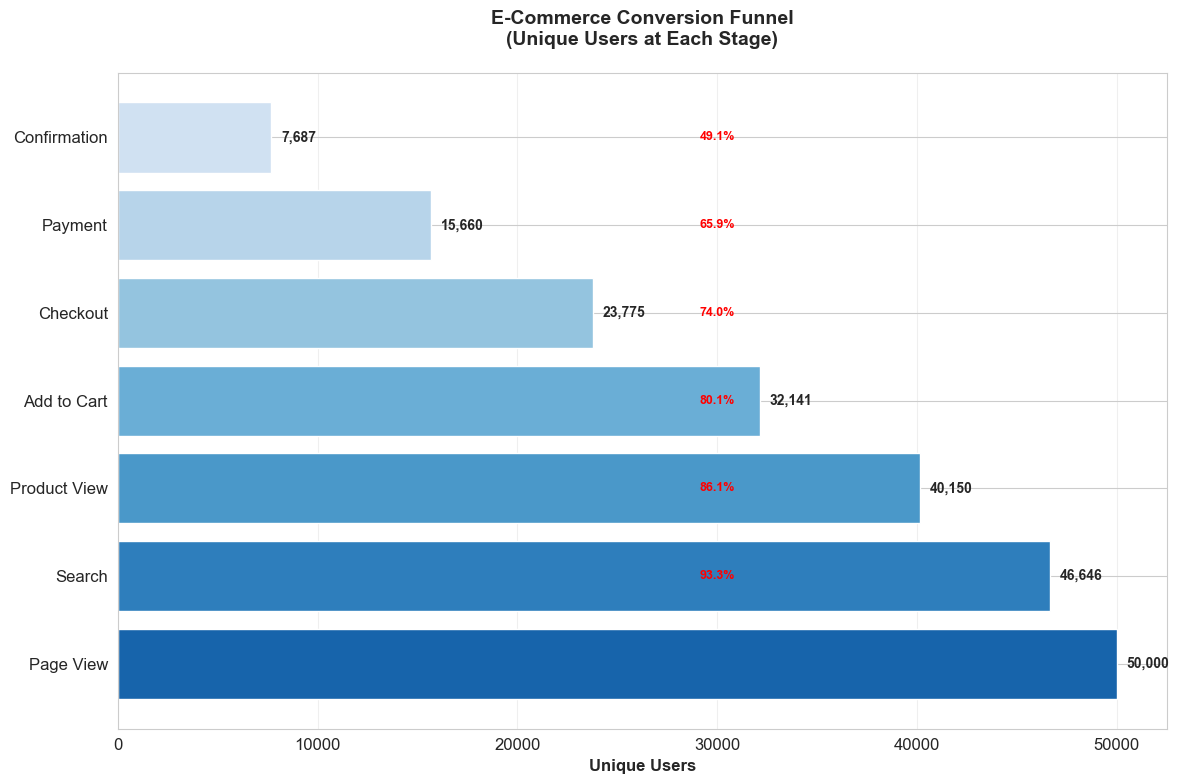

In [24]:
#Funnel Chart (Matplotlib)
fig, ax = plt.subplots(figsize=(12, 8))

stage_display = ['Page View', 'Search', 'Product View', 'Add to Cart', 
                 'Checkout', 'Payment', 'Confirmation']
stage_values = [df_clean[df_clean['event_stage'] == s]['user_id'].nunique() 
                for s in funnel_stages]

colors = plt.cm.Blues(np.linspace(0.8, 0.2, len(stage_values)))
bars = ax.barh(stage_display, stage_values, color=colors, edgecolor='white')

for i, (bar, val) in enumerate(zip(bars, stage_values)):
    ax.text(val + max(stage_values)*0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:,}', va='center', fontsize=10, fontweight='bold')
    if i > 0:
        conv = (stage_values[i] / stage_values[i-1] * 100)
        ax.text(max(stage_values)*0.6, bar.get_y() + bar.get_height()/2, 
                f'{conv:.1f}%', va='center', ha='center', 
                fontsize=9, color='red', fontweight='bold')

ax.set_xlabel('Unique Users', fontsize=12, fontweight='bold')
ax.set_title('E-Commerce Conversion Funnel\n(Unique Users at Each Stage)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Interactive Plotly Funnel Chart
fig = go.Figure(go.Funnel(
    y=stage_display,
    x=stage_values,
    textposition="inside",
    textinfo="value+percent initial",
    marker=dict(
        color=["#3498db", "#5dade2", "#85c1e9", "#a9cce3", "#d4e6f1", "#e8f8f5", "#7fb069"]
    )
))
fig.update_layout(
    title='Interactive Conversion Funnel (Plotly)',
    font=dict(family="Arial", size=12),
    width=800,
    height=600
)

fig.show()

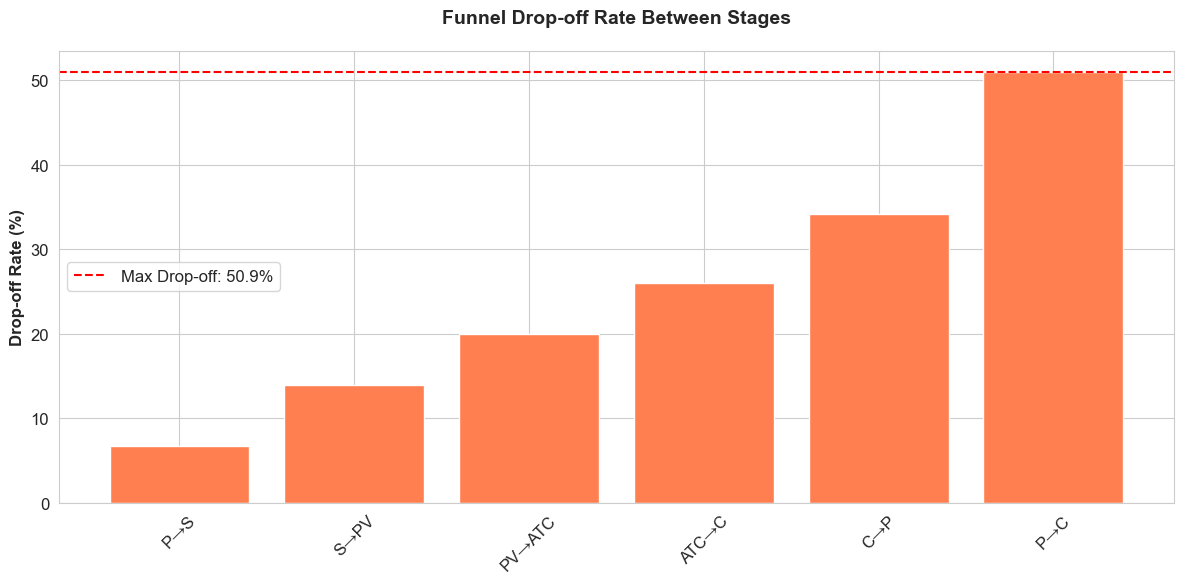

In [26]:
# Funnel Drop-off Analysis
fig, ax = plt.subplots(figsize=(12, 6))

drop_off = []
for i in range(1, len(stage_values)):
    drop = ((stage_values[i-1] - stage_values[i]) / stage_values[i-1] * 100)
    drop_off.append(drop)

stage_labels = ['P→S', 'S→PV', 'PV→ATC', 'ATC→C', 'C→P', 'P→C']
ax.bar(stage_labels, drop_off, color='coral', edgecolor='white')
ax.set_ylabel('Drop-off Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Funnel Drop-off Rate Between Stages', fontsize=14, fontweight='bold', pad=20)
ax.axhline(y=max(drop_off), color='red', linestyle='--',  label=f'Max Drop-off: {max(drop_off):.1f}%')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

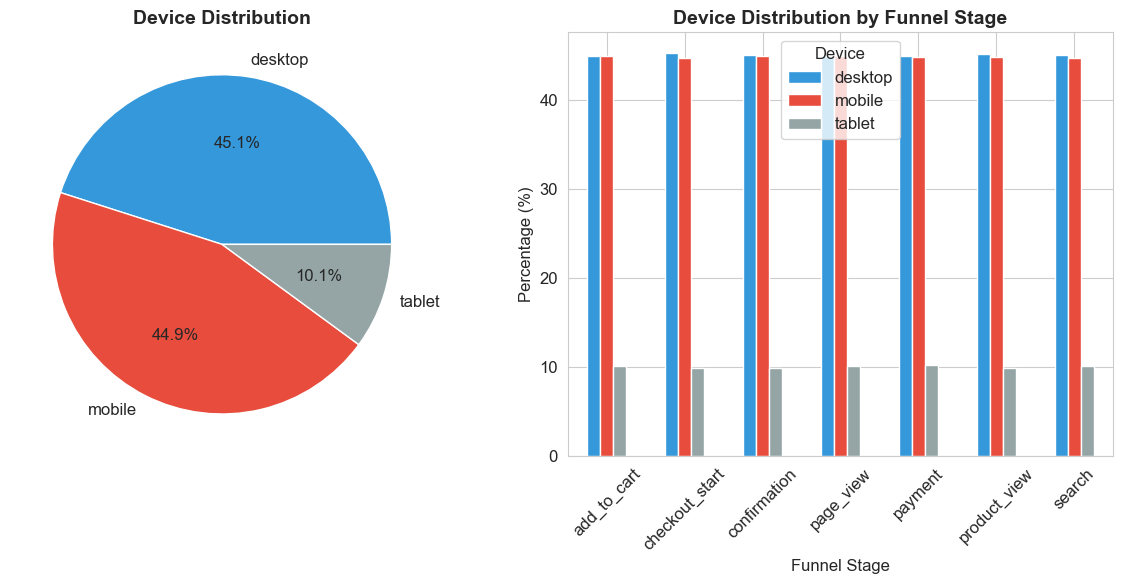

In [27]:
# Device Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

device_counts = df_clean['device'].value_counts()
axes[0].pie(device_counts.values, labels=device_counts.index, autopct='%1.1f%%',
           colors=['#3498db', '#e74c3c', '#95a5a6'])
axes[0].set_title('Device Distribution', fontsize=14, fontweight='bold')

device_funnel = pd.crosstab(df_clean['event_stage'], df_clean['device'])
device_funnel_pct = device_funnel.div(device_funnel.sum(axis=1), axis=0) * 100
device_funnel_pct.plot(kind='bar', ax=axes[1], figsize=(12, 6),
                       color=['#3498db', '#e74c3c', '#95a5a6'])
axes[1].set_xlabel('Funnel Stage', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Device Distribution by Funnel Stage', fontsize=14, fontweight='bold')
axes[1].legend(title='Device')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

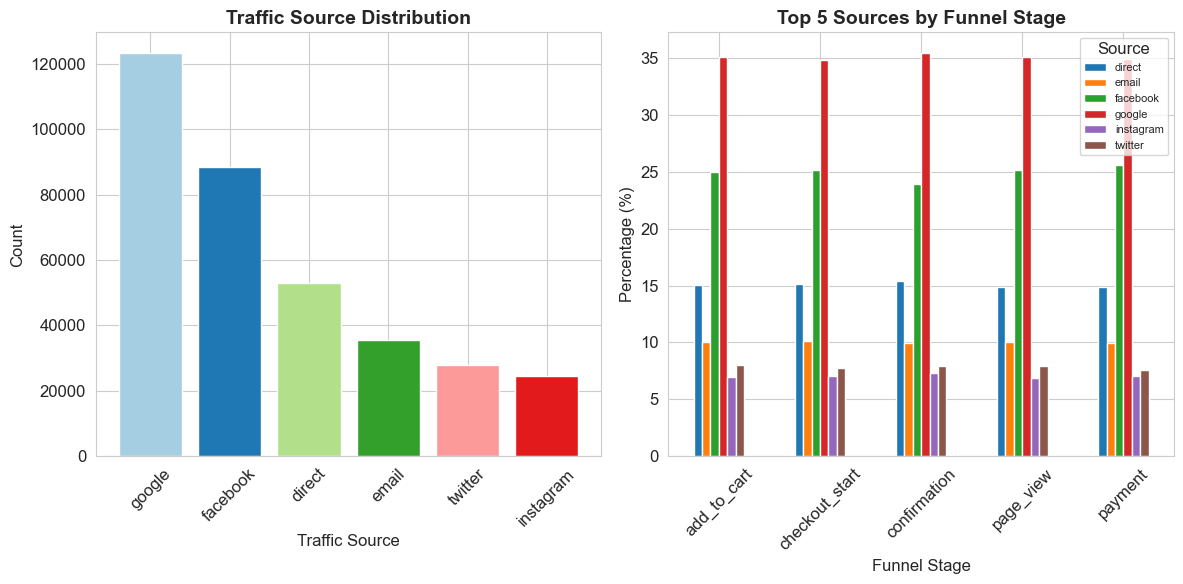

In [28]:
# Traffic Source Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

source_counts = df_clean['source'].value_counts()
axes[0].bar(source_counts.index, source_counts.values, 
           color=plt.cm.Paired(np.arange(len(source_counts))), edgecolor='white')
axes[0].set_xlabel('Traffic Source', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Traffic Source Distribution', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

source_funnel = pd.crosstab(df_clean['event_stage'], df_clean['source'])
source_funnel_pct = source_funnel.div(source_funnel.sum(axis=1), axis=0) * 100
source_funnel_pct.head(5).plot(kind='bar', ax=axes[1], figsize=(12, 6))
axes[1].set_xlabel('Funnel Stage', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Top 5 Sources by Funnel Stage', fontsize=14, fontweight='bold')
axes[1].legend(title='Source', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

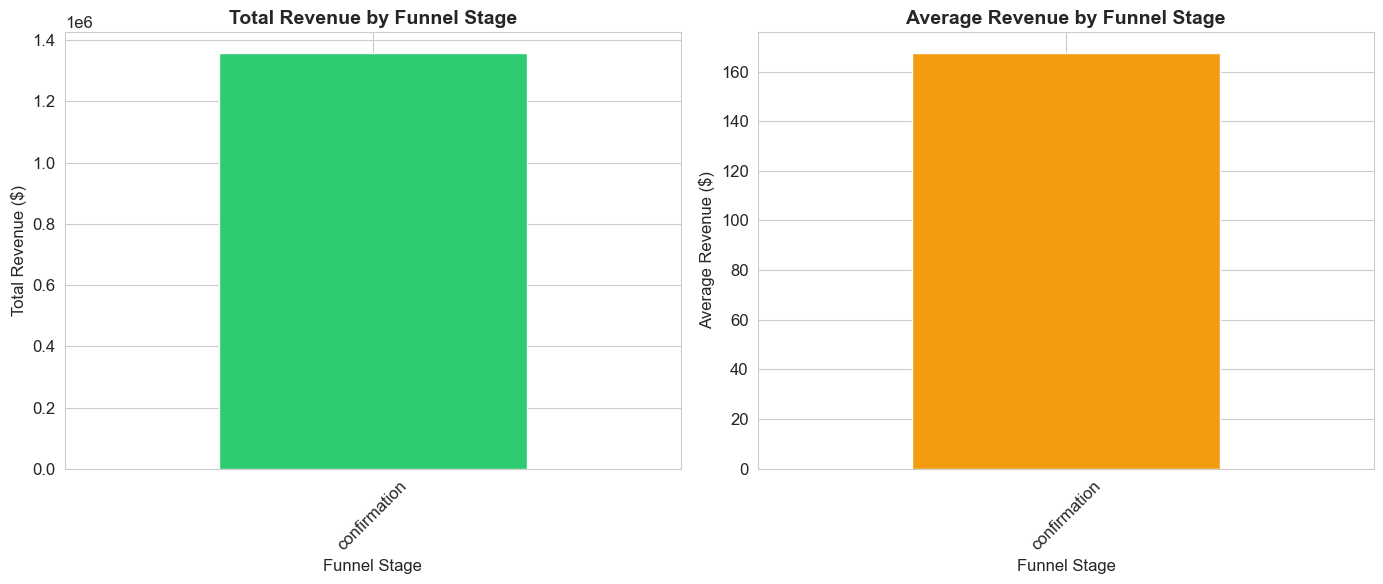

In [29]:
# Revenue Analysis by Stage
revenue_by_stage = df_clean[df_clean['revenue'].notnull()].groupby('event_stage')['revenue'].agg(['sum', 'mean', 'count'])
revenue_by_stage.columns = ['Total_Revenue', 'Avg_Revenue', 'Transaction_Count']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
revenue_by_stage['Total_Revenue'].plot(kind='bar', ax=axes[0], 
                                        color='#2ecc71', edgecolor='white')
axes[0].set_xlabel('Funnel Stage', fontsize=12)
axes[0].set_ylabel('Total Revenue ($)', fontsize=12)
axes[0].set_title('Total Revenue by Funnel Stage', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

revenue_by_stage['Avg_Revenue'].plot(kind='bar', ax=axes[1], 
                                      color='#f39c12', edgecolor='white')
axes[1].set_xlabel('Funnel Stage', fontsize=12)
axes[1].set_ylabel('Average Revenue ($)', fontsize=12)
axes[1].set_title('Average Revenue by Funnel Stage', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [30]:
#  Country Analysis
top_countries = df_clean['country'].value_counts().head(10)
fig = px.pie(values=top_countries.values, names=top_countries.index,
            title='Customer Distribution by Country',color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

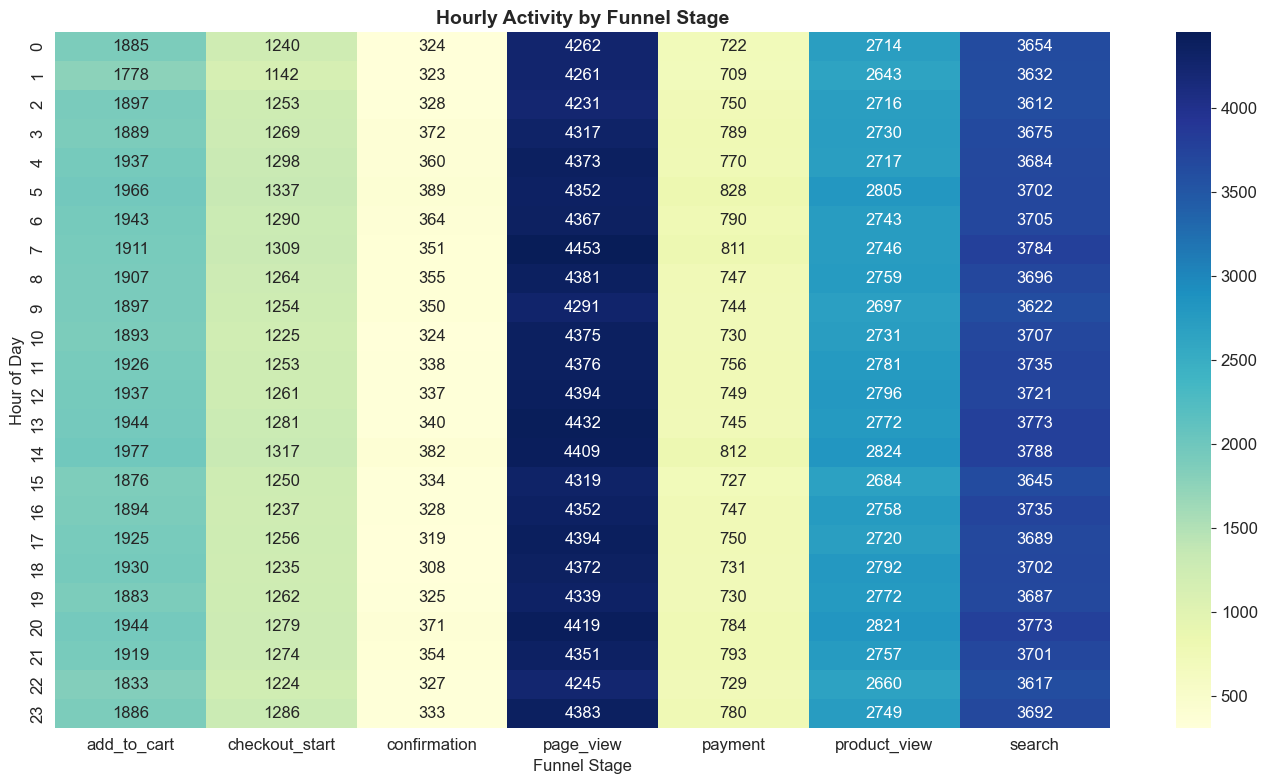

In [31]:
# Hourly Activity Heatmap
hourly_activity = pd.crosstab(df_clean['event_hour'], df_clean['event_stage'])
plt.figure(figsize=(14, 8))
sns.heatmap(hourly_activity, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Hourly Activity by Funnel Stage', fontsize=14, fontweight='bold')
plt.xlabel('Funnel Stage', fontsize=12)
plt.ylabel('Hour of Day', fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
print(f"Key Findings:")
print(f"1. Total unique users: {df_clean['user_id'].nunique()}")
print(f"2. Total conversions: {df_clean[df_clean['event_stage']=='confirmation']['user_id'].nunique()}")
print(f"3. Overall conversion rate: {df_clean[df_clean['event_stage']=='confirmation']['user_id'].nunique() / df_clean[df_clean['event_stage']=='page_view']['user_id'].nunique() * 100:.2f}%")

Key Findings:
1. Total unique users: 50000
2. Total conversions: 7687
3. Overall conversion rate: 15.37%
